# 4. Sa se normalizeze informatiile de la problema 1 si 2 folosind diferite metode de normalizare astfel:
    - problema 1 - durata anilor de studii universitare, vechimea in programare
    - problema 2 - valorile pixelilor din imagini
    - problema 3 - numarul de aparitii a cuvintelor la nivelul unei propozitii.

In [1]:
import csv
import os
from math import log
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from nltk import word_tokenize, sent_tokenize

## problema 1 - durata anilor de studii universitare, vechimea in programare

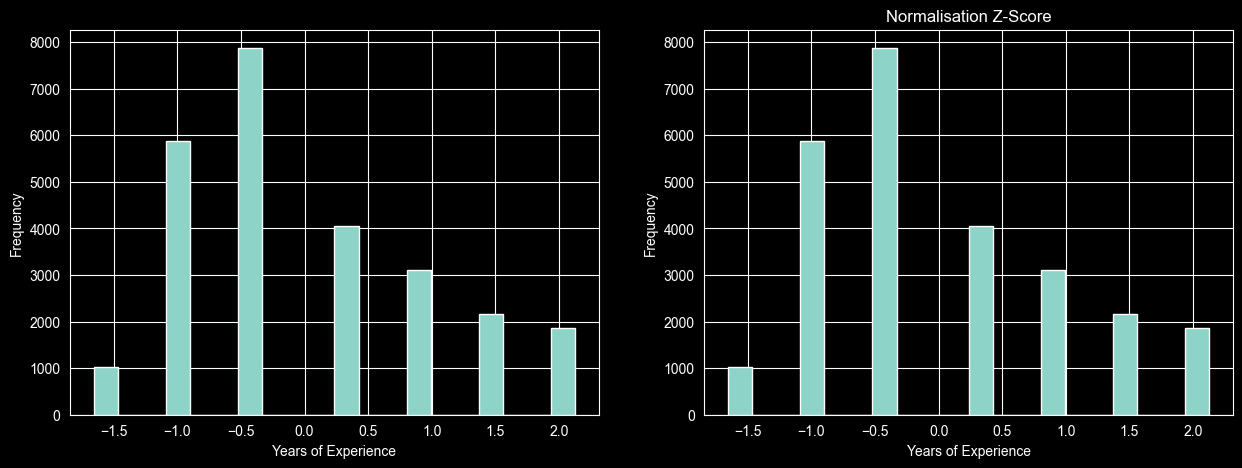

In [5]:
def problem1():
    def loadDataMoreInputs(fileName):
        data = []
        dataNames = []
        with open(fileName) as csv_file:
            csv_reader = csv.reader(csv_file, delimiter=',')
            line_count = 0
            for row in csv_reader:
                if line_count == 1:
                    dataNames = row
                elif line_count > 1:
                    data.append(row)
                line_count += 1
        return dataNames, data

    # Extract the relevant columns
    def extractFeature(allData, names, featureName):
        pos = names.index(featureName)
        return [data[pos] for data in allData]

    def minMaxYearsNormalisation():
        # Extract the relevant columns
        names, allData = loadDataMoreInputs('data/surveyDataScience.csv')

        # Extract the features
        educationFeature = extractFeature(allData, names, "What is the highest level of formal education that you have attained or plan to attain within the next 2 years?")
        educationToYears = {
            "No formal education past high school" : 12,
            "Some college/university study without earning a bachelor’s degree" : 14,
            "Bachelor’s degree" : 16,
            "Master’s degree" : 18,
            "Professional doctorate" : 20,
            "Doctoral degree" : 21,
            "I prefer not to answer" : None
        }
        yearsOfStudy = [educationToYears.get(data) for data in educationFeature]
        cleanDataYearsOfStudy = [years for years in yearsOfStudy if years is not None]
        normalisedYearsOfStudy = [(years - min(cleanDataYearsOfStudy)) / (max(cleanDataYearsOfStudy) - min(cleanDataYearsOfStudy)) for years in cleanDataYearsOfStudy]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.hist(cleanDataYearsOfStudy, 20)
        ax1.set_xlabel("Years of Study")
        ax1.set_ylabel("Frequency")
        ax2.hist(normalisedYearsOfStudy, 20)
        ax2.set_xlabel("Years of Study")
        ax2.set_ylabel("Frequency")
        ax2.set_title("Normalisation Min-Max")
        plt.show()

    minMaxYearsNormalisation()

    def ZExperienceNormalisation():
        # Extract the relevant columns
        names, allData = loadDataMoreInputs('data/surveyDataScience.csv')

        # Extract the features
        experienceFeature = extractFeature(allData, names, "For how many years have you been writing code and/or programming?")
        educationToYears = {
            'I have never written code' : 0,
            '< 1 years' : 1,
            '1-3 years' : 2,
            '3-5 years' : 3,
            '5-10 years': 4,
            '10-20 years' : 5,
            '20+ years' : 6
        }
        yearsOfExperience = [educationToYears.get(data) for data in experienceFeature]
        m = sum(yearsOfExperience) / len(yearsOfExperience)
        s = (1 / len(yearsOfExperience) * sum([(mi - m) ** 2 for mi in yearsOfExperience])) ** 0.5
        normalisedYearsOfExperience = [(mi - m) / s for mi in yearsOfExperience]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.hist(normalisedYearsOfExperience, 20)
        ax1.set_xlabel("Years of Experience")
        ax1.set_ylabel("Frequency")
        ax2.hist(normalisedYearsOfExperience, 20)
        ax2.set_xlabel("Years of Experience")
        ax2.set_ylabel("Frequency")
        ax2.set_title("Normalisation Z-Score")
        plt.show()

    minMaxYearsNormalisation()
    ZExperienceNormalisation()

problem1()

## problema 2 - valorile pixelilor din imagini

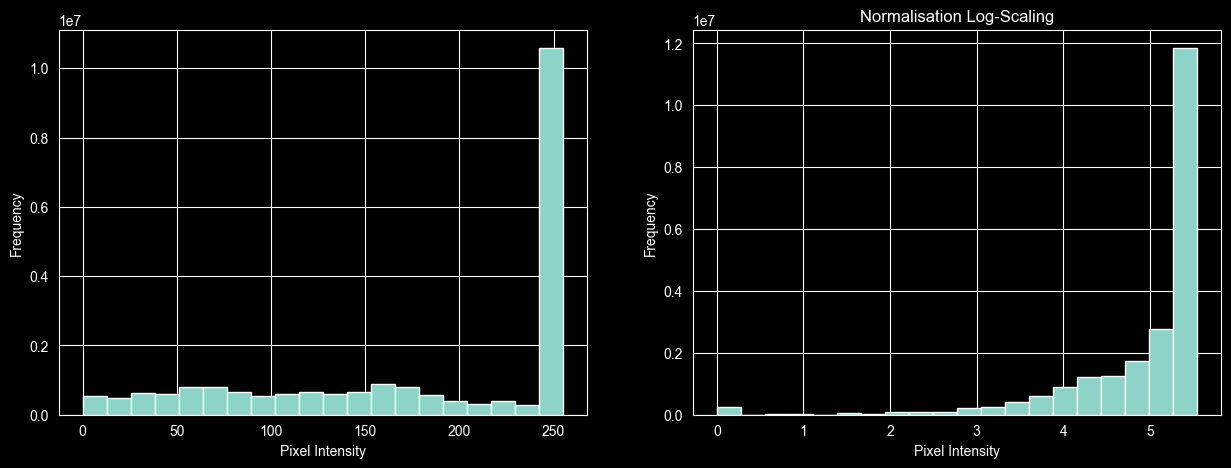

In [6]:
def problem2():
    images_folder_path = 'data/images'
    images = []
    for file in os.listdir(images_folder_path):
        path = os.path.join(images_folder_path, file)
        image = Image.open(path)
        images.append(image)

    pixels = []
    for image in images:
        image_pixels = np.array(image)
        pixels.extend(image_pixels.flatten())
    pixels_log = [log(int(pixel) + 1) for pixel in pixels]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.hist(pixels, 20)
    ax1.set_xlabel("Pixel Intensity")
    ax1.set_ylabel("Frequency")
    ax2.hist(pixels_log, 20)
    ax2.set_xlabel("Pixel Intensity")
    ax2.set_ylabel("Frequency")
    ax2.set_title("Normalisation Log-Scaling")
    plt.show()

problem2()

## problema 3 - numarul de aparitii a cuvintelor la nivelul unei propozitii.

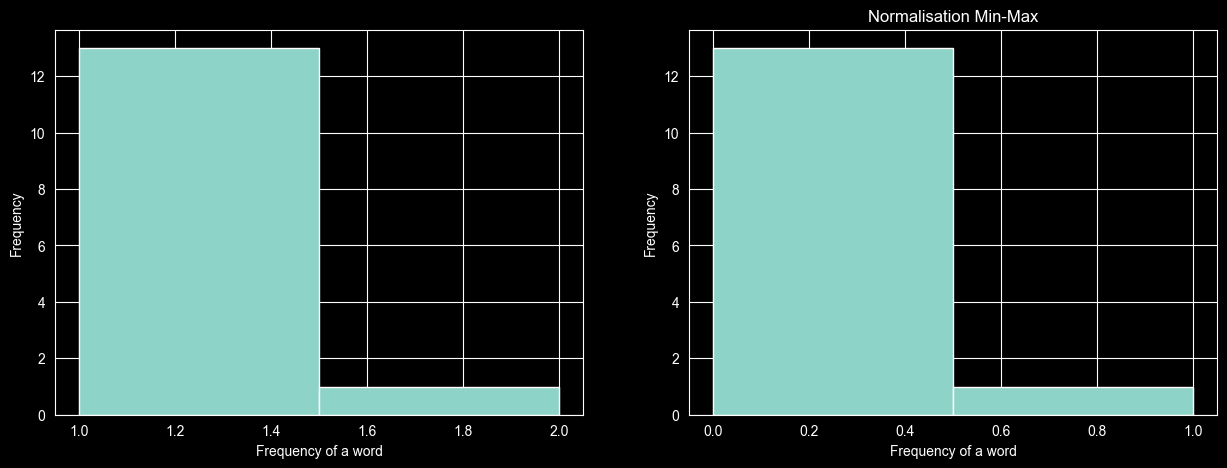

In [7]:
def problem3():
    with open("data/texts.txt", "r", encoding="utf-8") as file:
        text = file.read()
    sentences = sent_tokenize(text)
    words = [w for w in word_tokenize(sentences[0]) if w.isalpha()]
    frequency = {}
    for word in words:
        frequency[word.lower()] = frequency.get(word.lower(), 0) + 1
    counts = list(frequency.values())
    countsMinMax = [(count - min(counts)) / (max(counts) - min(counts)) for count in counts]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.hist(counts, 2)
    ax1.set_xlabel("Frequency of a word")
    ax1.set_ylabel("Frequency")
    ax2.hist(countsMinMax, 2)
    ax2.set_xlabel("Frequency of a word")
    ax2.set_ylabel("Frequency")
    ax2.set_title("Normalisation Min-Max")
    plt.show()

problem3()